# 04. Stromal Microenvironment Analysis

## Objective

Characterise stromal-cell heterogeneity within the CID4465 TNBC tumour, focusing on cancer-associated fibroblasts, perivascular-like cells and endothelial cells.

## Main goals

1. Extract the stromal compartment.
2. Recompute dimensionality reduction within stromal cells.
3. Identify stromal-specific transcriptional structure.
4. Characterise fibroblast/ECM programmes.
5. Characterise perivascular and vascular programmes.
6. Evaluate whether stromal populations contain stable subclusters or continuous cell states.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

print("Core libraries loaded successfully.")

Core libraries loaded successfully.


In [2]:
project_dir = Path.cwd().parent

data_dir = project_dir / "data"
processed_dir = data_dir / "processed"
figures_dir = project_dir / "figures"
results_dir = project_dir / "results"

processed_file = processed_dir / "CID4465_processed.h5ad"

adata = sc.read_h5ad(processed_file)

print(adata)

AnnData object with n_obs × n_vars = 1534 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)


In [3]:
stromal_celltypes = [
    "CAFs",
    "PVL",
    "Endothelial"
]

adata_stromal = adata[
    adata.obs["predicted_celltype"].isin(stromal_celltypes)
].copy()

print("Stromal AnnData:")
print(adata_stromal)

print("\nStromal cell-type distribution:")
print(
    adata_stromal.obs["predicted_celltype"]
    .value_counts()
)

print(
    "\nTotal stromal cells:",
    adata_stromal.n_obs
)

Stromal AnnData:
AnnData object with n_obs × n_vars = 978 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)

Stromal cell-type distribution:
predicted_celltype
CAFs           374
PVL            317
Endothelial    287
Name: count, dtype: int64

Total stromal cells: 978


In [4]:
sc.pp.highly_variable_genes(
    adata_stromal,
    n_top_genes=1500,
    flavor="seurat"
)

print(
    "Stromal highly variable genes:",
    adata_stromal.var["highly_variable"].sum()
)

Stromal highly variable genes: 1500


In [5]:
adata_stromal_hvg = adata_stromal[
    :,
    adata_stromal.var["highly_variable"]
].copy()

print(adata_stromal_hvg)

AnnData object with n_obs × n_vars = 978 × 1500
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)


In [6]:
sc.pp.scale(
    adata_stromal_hvg,
    max_value=10
)

sc.tl.pca(
    adata_stromal_hvg,
    n_comps=30,
    svd_solver="arpack"
)

print(
    "Stromal PCA shape:",
    adata_stromal_hvg.obsm["X_pca"].shape
)

/opt/anaconda3/envs/cancer-informatics/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Stromal PCA shape: (978, 30)


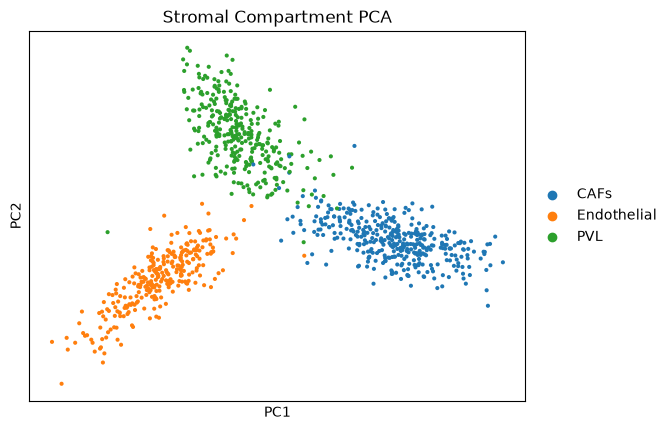

In [7]:
sc.pl.pca(
    adata_stromal_hvg,
    color="predicted_celltype",
    size=35,
    title="Stromal Compartment PCA"
)

In [8]:
# Build stromal nearest-neighbour graph

sc.pp.neighbors(
    adata_stromal_hvg,
    n_neighbors=15,
    n_pcs=15
)

print("Stromal neighbour graph constructed.")

/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Stromal neighbour graph constructed.


In [9]:
# Stromal UMAP

sc.tl.umap(
    adata_stromal_hvg,
    random_state=42
)

print("Stromal UMAP complete.")

Stromal UMAP complete.


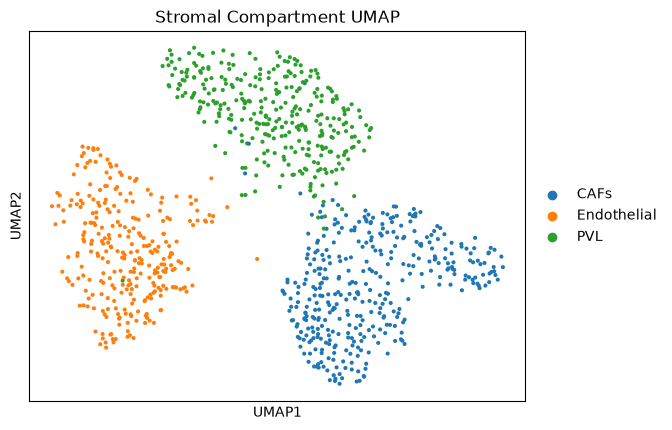

In [10]:
sc.pl.umap(
    adata_stromal_hvg,
    color="predicted_celltype",
    size=35,
    title="Stromal Compartment UMAP"
)

In [11]:
# Stromal-specific Leiden clustering

sc.tl.leiden(
    adata_stromal_hvg,
    resolution=0.4,
    key_added="stromal_leiden",
    flavor="igraph",
    n_iterations=2,
    directed=False,
    random_state=42
)

print("Stromal Leiden clustering complete.")

print("\nCluster distribution:")
print(
    adata_stromal_hvg.obs["stromal_leiden"]
    .value_counts()
    .sort_index()
)

Stromal Leiden clustering complete.

Cluster distribution:
stromal_leiden
0    285
1    165
2    213
3    315
Name: count, dtype: int64


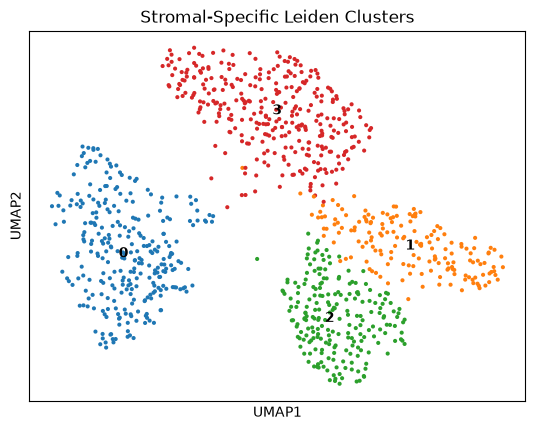

In [12]:
sc.pl.umap(
    adata_stromal_hvg,
    color="stromal_leiden",
    legend_loc="on data",
    size=35,
    title="Stromal-Specific Leiden Clusters"
)

In [13]:
stromal_cluster_table = pd.crosstab(
    adata_stromal_hvg.obs["stromal_leiden"],
    adata_stromal_hvg.obs["predicted_celltype"]
)

display(stromal_cluster_table)

predicted_celltype,CAFs,Endothelial,PVL
stromal_leiden,,,
0,0,284,1
1,158,0,7
2,212,1,0
3,4,2,309


In [14]:
# Transfer stromal clustering back to full-gene object

adata_stromal.obs["stromal_leiden"] = (
    adata_stromal_hvg.obs["stromal_leiden"].copy()
)

adata_stromal.obsm["X_umap"] = (
    adata_stromal_hvg.obsm["X_umap"].copy()
)

print("Stromal cluster labels transferred.")

Stromal cluster labels transferred.


In [15]:
# Identify stromal cluster marker genes

sc.tl.rank_genes_groups(
    adata_stromal,
    groupby="stromal_leiden",
    method="wilcoxon",
    key_added="stromal_markers"
)

stromal_marker_df = sc.get.rank_genes_groups_df(
    adata_stromal,
    group=None,
    key="stromal_markers"
)

print("Stromal marker analysis complete.")

Stromal marker analysis complete.


In [16]:
for cluster in sorted(
    adata_stromal.obs["stromal_leiden"].unique(),
    key=int
):
    top_genes = (
        stromal_marker_df[
            stromal_marker_df["group"] == cluster
        ]
        .head(15)["names"]
        .tolist()
    )

    print(
        f"Cluster {cluster}:",
        ", ".join(top_genes)
    )

Cluster 0: CD74, PLVAP, FKBP1A, HLA-DRB1, HYAL2, HLA-DRB5, VWF, ACKR1, TM4SF1, CRIP2, HSPG2, HLA-B, TMSB4X, ADGRL4, ARL4A
Cluster 1: DCN, C1S, LUM, APOD, SFRP2, SFRP4, C1R, MGP, CST3, CXCL14, CCDC80, RARRES1, C3, CD63, EFEMP1
Cluster 2: COL1A1, CTHRC1, COL1A2, LUM, COL3A1, FN1, POSTN, SFRP2, MFAP2, LGALS1, DCN, RARRES2, MMP11, SPARC, MDK
Cluster 3: ACTA2, NDUFA4L2, PTP4A3, PTMA, IGFBP7, SPARCL1, MYL9, ADIRF, COL18A1, RGS5, SOD3, CALM2, H3F3B, TAGLN, DSTN


In [17]:
stromal_cluster_labels = {
    "0": "Endothelial",
    "1": "SFRP2/LUM CAF",
    "2": "CTHRC1/POSTN CAF",
    "3": "PVL"
}

adata_stromal.obs["stromal_state"] = (
    adata_stromal.obs["stromal_leiden"]
    .map(stromal_cluster_labels)
)

print(
    adata_stromal.obs["stromal_state"]
    .value_counts()
)

stromal_state
PVL                 315
Endothelial         285
CTHRC1/POSTN CAF    213
SFRP2/LUM CAF       165
Name: count, dtype: int64


In [18]:
adata_stromal_hvg.obs["stromal_state"] = (
    adata_stromal.obs["stromal_state"].copy()
)

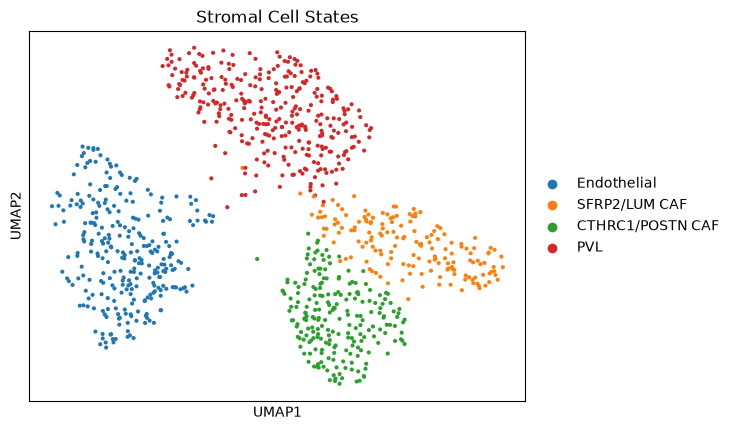

In [19]:
sc.pl.umap(
    adata_stromal_hvg,
    color="stromal_state",
    size=35,
    title="Stromal Cell States"
)

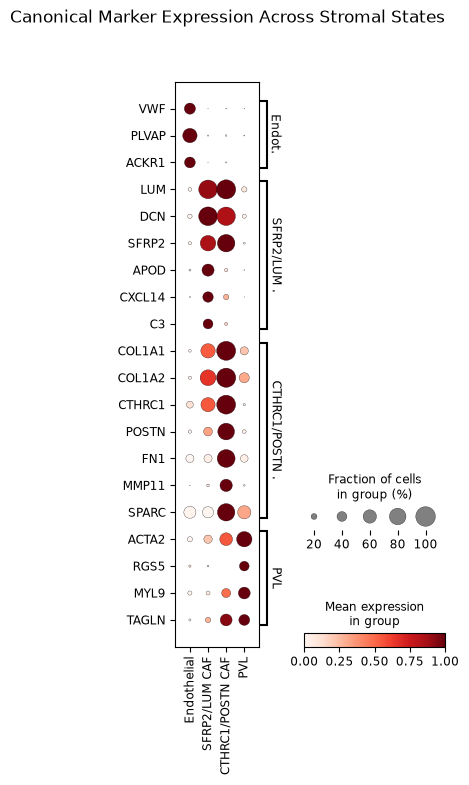

In [20]:
stromal_marker_panel = {
    "Endothelial": [
        "VWF", "PLVAP", "ACKR1"
    ],
    "SFRP2/LUM CAF": [
        "LUM", "DCN", "SFRP2",
        "APOD", "CXCL14", "C3"
    ],
    "CTHRC1/POSTN CAF": [
        "COL1A1", "COL1A2", "CTHRC1",
        "POSTN", "FN1", "MMP11", "SPARC"
    ],
    "PVL": [
        "ACTA2", "RGS5", "MYL9", "TAGLN"
    ]
}

stromal_marker_panel = {
    group: [
        gene for gene in genes
        if gene in adata_stromal.var_names
    ]
    for group, genes in stromal_marker_panel.items()
}

sc.pl.dotplot(
    adata_stromal,
    stromal_marker_panel,
    groupby="stromal_state",
    standard_scale="var",
    swap_axes=True,
    title="Canonical Marker Expression Across Stromal States"
)

In [21]:
stromal_state_counts = (
    adata_stromal.obs["stromal_state"]
    .value_counts()
)

stromal_state_percent = (
    stromal_state_counts / adata_stromal.n_obs * 100
)

stromal_state_df = pd.DataFrame({
    "cell_count": stromal_state_counts,
    "percentage": stromal_state_percent
})

display(stromal_state_df.round(2))

stromal_state_df.to_csv(
    results_dir / "04_stromal_state_composition.csv"
)

,cell_count,percentage
stromal_state,,
PVL,315,32.21
Endothelial,285,29.14
CTHRC1/POSTN CAF,213,21.78
SFRP2/LUM CAF,165,16.87


In [22]:
print("=== FINAL STROMAL MICROENVIRONMENT QC ===")

print(f"Total stromal cells: {adata_stromal.n_obs}")

print("\nOriginal stromal cell types:")
print(
    adata_stromal.obs["predicted_celltype"]
    .value_counts()
)

print("\nStromal Leiden clusters:")
print(
    adata_stromal.obs["stromal_leiden"]
    .value_counts()
    .sort_index()
)

print("\nAnnotated stromal states:")
print(
    adata_stromal.obs["stromal_state"]
    .value_counts()
)

print("\nKey CAF programmes:")

print(
    "SFRP2/LUM CAF:",
    "LUM, DCN, SFRP2, APOD, CXCL14, C3"
)

print(
    "CTHRC1/POSTN CAF:",
    "COL1A1, COL1A2, CTHRC1, POSTN, FN1, MMP11, SPARC"
)

=== FINAL STROMAL MICROENVIRONMENT QC ===
Total stromal cells: 978

Original stromal cell types:
predicted_celltype
CAFs           374
PVL            317
Endothelial    287
Name: count, dtype: int64

Stromal Leiden clusters:
stromal_leiden
0    285
1    165
2    213
3    315
Name: count, dtype: int64

Annotated stromal states:
stromal_state
PVL                 315
Endothelial         285
CTHRC1/POSTN CAF    213
SFRP2/LUM CAF       165
Name: count, dtype: int64

Key CAF programmes:
SFRP2/LUM CAF: LUM, DCN, SFRP2, APOD, CXCL14, C3
CTHRC1/POSTN CAF: COL1A1, COL1A2, CTHRC1, POSTN, FN1, MMP11, SPARC


## Conclusion

Stromal-cell reclustering revealed four major transcriptional states within the CID4465 TNBC tumour: endothelial cells, perivascular-like cells, and two distinct cancer-associated fibroblast populations.

The first CAF population expressed SFRP2, LUM, DCN, APOD and CXCL14, consistent with a fibroblast-like stromal programme.

The second CAF population showed strong expression of COL1A1, COL1A2, CTHRC1, POSTN, FN1 and MMP11, indicating a more activated extracellular-matrix-remodelling programme.

These results demonstrate substantial stromal heterogeneity and show that the CAF compartment cannot be represented as a single transcriptional population.